### $$\text{OPTIMIZACIÓN HIPERPARÁMETROS DE MODELOS}$$

En este cuaderno se realiza la optimización de hiperparámetros aplicada a los modelos XGBoost.

Se utilizarán 4 métodos:

> - Búsqueda de cuadrícula/grilla "Grid Search" - métrica Log-loss

> - Búsqueda aleatoria "Randomized Search" - métrica Log-loss

> - Optimización Bayesiana optuna - métrica Log-loss

> - Optimización Bayesiana optuna - métrica F1-Score

**Orden del cuaderno:**

> 0. Modelo XGBoost base

> 1. Grid Search

> 2. Randomized Search

> 3. Optimización Bayesiana optuna - métrica Log-loss

> 4. Optimización Bayesiana optuna - métrica F1-Score

> 5. Comparación de resultados

# 0. Modelo base

In [1]:
# Módulos para manipulación de datos y visualización
import pandas as pd
import numpy as np
import io # Usado para cargar datos de ejemplo desde un string
import matplotlib.pyplot as plt
import seaborn as sns
import tabulate

# Preprocesamiento y Pipelines
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Métricas
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import precision_score, recall_score

# Configuraciones generales para el cuaderno
sns.set_style('whitegrid') #Estilo de gráficos seaborn
pd.set_option('display.max_columns', None) # Mostrar todas las columnas de un DataFrame

Leer archivo con df_trabajo:

In [2]:
dftrabajo = pd.read_csv('../data/df_trabajo_sesiones.csv', sep=",")

In [3]:
dftrabajo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22284 entries, 0 to 22283
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   pais                 22284 non-null  object 
 1   num_visitas          22284 non-null  int64  
 2   numero_modelos       22284 non-null  int64  
 3   pagina_mas_visitada  22284 non-null  object 
 4   precio_maximo        22284 non-null  int64  
 5   precio_promedio      22284 non-null  float64
 6   visitaspag1trousers  22284 non-null  float64
 7   visitaspag2skirts    22284 non-null  float64
 8   visitaspag3blouses   22284 non-null  float64
 9   visitaspag4sales     22284 non-null  float64
 10  target               22284 non-null  int64  
dtypes: float64(5), int64(4), object(2)
memory usage: 1.9+ MB


Pipelines:

In [4]:
numeric_features = ['num_visitas', 'numero_modelos', 'precio_maximo', 'precio_promedio', 'visitaspag1trousers', 'visitaspag2skirts', 'visitaspag3blouses']

# Seleccionar automáticamente todas las columnas 'object' como categóricas
categorical_features = dftrabajo.select_dtypes(include=['object', 'category']).columns.tolist()

# Asegurarnos de que las numéricas no estén en la lista de categóricas
categorical_features = [col for col in categorical_features if col not in numeric_features and col != 'target' and col != 'visitaspag4sales']

print(f"Features/variables Numéricas: {numeric_features}")
print(f"Features/variables Categóricas: {categorical_features}")

Features/variables Numéricas: ['num_visitas', 'numero_modelos', 'precio_maximo', 'precio_promedio', 'visitaspag1trousers', 'visitaspag2skirts', 'visitaspag3blouses']
Features/variables Categóricas: ['pais', 'pagina_mas_visitada']


Transformadores:

In [5]:
# Crear el transformador para variables numéricas
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Imputar NAs con la mediana
    ('scaler', StandardScaler())                 # Escala los datos.
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Imputar NAs con la moda
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))   # Aplicar One-Hot Encoding
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # Dejar pasar cualquier columna no especificada directamente
)

preprocessor
print("\n\nPreprocesador creado exitosamente!")



Preprocesador creado exitosamente!


División de datos:

In [6]:
X = dftrabajo.drop(['target', 'visitaspag4sales'], axis=1)
y = dftrabajo['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamaño de X Train: {X_train.shape}")
print(f"Tamaño de X Test: {X_test.shape}")

print(f"Tamaño de y Train: {y_train.shape}")
print(f"Tamaño de y Test: {y_test.shape}")

Tamaño de X Train: (17827, 9)
Tamaño de X Test: (4457, 9)
Tamaño de y Train: (17827,)
Tamaño de y Test: (4457,)


XGBOOST base:

In [7]:
# Cálculo de 'scale_pos_weight' para ingresar como parámetro en modelos de boosting
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"Scale Pos Weight: {scale_pos_weight:.2f}")

# Definir pipeline de entrenamiento de modelo
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        random_state=42, 
        use_label_encoder=False, 
        eval_metric='logloss', # Función de pérdida/costo a minimizar
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight # Ayudar con el desbalanceo
    ))
])

# Entrenar el pipeline
print("Entrenando el Pipeline de XGBoost...")
xgb_pipeline.fit(X_train, y_train)
print("Entrenamiento completado.")

# Evaluar modelo
y_pred_xgb = xgb_pipeline.predict(X_test)
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

print("\n--- Reporte de Clasificación (XGBoost) ---")
print(classification_report(y_test, y_pred_xgb))

# Guardar métricas en objetos
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb, pos_label=1)
xgb_auc = roc_auc_score(y_test, y_prob_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb, pos_label=1)
xgb_recall = recall_score(y_test, y_pred_xgb, pos_label=1)

Scale Pos Weight: 1.99
Entrenando el Pipeline de XGBoost...


c:\Users\HP ENVY\AppData\Local\pypoetry\Cache\virtualenvs\ejercicio-clase-boosting-LZc5TFcY-py3.11\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:03:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Entrenamiento completado.

--- Reporte de Clasificación (XGBoost) ---
              precision    recall  f1-score   support

           0       0.80      0.67      0.73      2967
           1       0.51      0.67      0.58      1490

    accuracy                           0.67      4457
   macro avg       0.65      0.67      0.65      4457
weighted avg       0.70      0.67      0.68      4457



Determinar los ``cv_splits``

El flujo de trabajo estándar en Machine Learning siempre comienza con una partición de Train/Test y luego usa la ***validación cruzada (StratifiedKFold) solo en el conjunto de entrenamiento(Train)***.

In [8]:
# Para validación cruzada con estratificación
from sklearn.model_selection import StratifiedKFold 

# Crear 5 grupos basados en el valor del CLV
y_bins = pd.cut(y_train, bins=5, labels=False)

# Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_splits = list(skf.split(X_train, y_bins))
print(f"Validación configurada: 5 Folds estratificados por valor del cliente.")

Validación configurada: 5 Folds estratificados por valor del cliente.


In [9]:
cv_splits

[(array([    1,     2,     3, ..., 17823, 17824, 17826], shape=(14261,)),
  array([    0,    11,    17, ..., 17818, 17820, 17825], shape=(3566,))),
 (array([    0,     1,     4, ..., 17824, 17825, 17826], shape=(14261,)),
  array([    2,     3,     6, ..., 17796, 17799, 17815], shape=(3566,))),
 (array([    0,     1,     2, ..., 17822, 17825, 17826], shape=(14262,)),
  array([    5,     8,    13, ..., 17821, 17823, 17824], shape=(3565,))),
 (array([    0,     2,     3, ..., 17823, 17824, 17825], shape=(14262,)),
  array([    1,     4,    10, ..., 17807, 17810, 17826], shape=(3565,))),
 (array([    0,     1,     2, ..., 17824, 17825, 17826], shape=(14262,)),
  array([   12,    23,    25, ..., 17813, 17816, 17822], shape=(3565,)))]

# 1. Grid Search

## a. Importar librerías

In [10]:
# Para búsqueda de hiperparámetros
from sklearn.model_selection import GridSearchCV

## b. Definir un diccionario de parámetros

Posibles hiperparámetros del `XGBClassifier`:

1. Parámetros de Booster (Controlan el modelo de árbol)

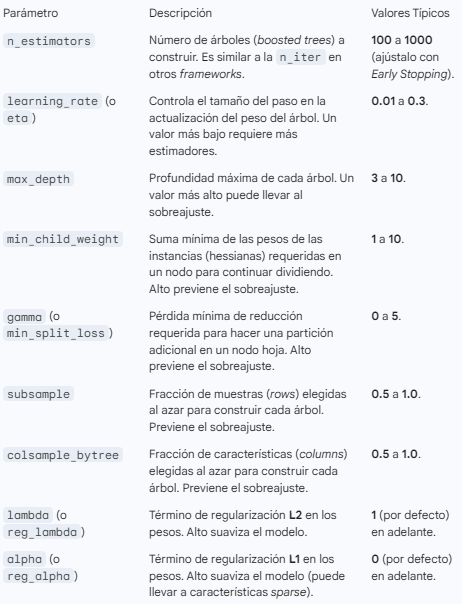

2. Parámetros de Tareas (Objetivo y Evaluación): Estos definen cómo se entrena y se evalúa el modelo para la clasificación.

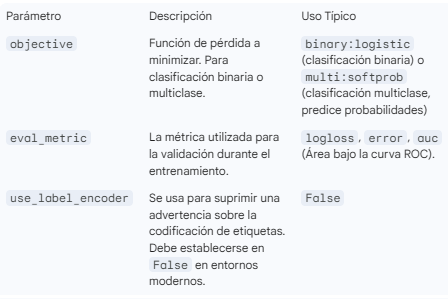

3. Parámetros Generales

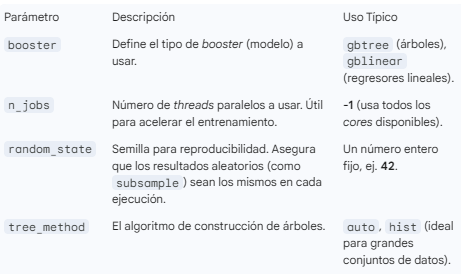

De los posibles hiperparámetros que se pueden optimizar, se eligieron:

- `n_estimators`
- `learning_rate`
- `max_depth`
- `min_split_loss`

In [11]:
param_grid = {
    'model__n_estimators': [100, 300, 500],
    'model__learning_rate': [0.01, 0.1],
    'model__max_depth': [3, 6, 9],
    'model__min_split_loss': [0, 1, 5]
}

## c. Declarar el objeto con las características del 'GridSearchCV'

In [12]:
grid_search = GridSearchCV(
    xgb_pipeline, # Pipeline que incluye preprocesamiento y modelo
    param_grid, # Parámetros a probar con los valores predefinidos
    cv=cv_splits, # Usar los folds estratificados del 'StratifiedKFold'
    scoring='neg_log_loss', # Equivalente a minimizar el log loss
    n_jobs=-1, # Usar todos los núcleos disponibles para paralelizar
    verbose=1 # Mostrar progreso
)

## d. Aplicar el 'fit': Reentrenar el modelo con los mejores valores de hiperparámetros

In [13]:
print("Iniciando búsqueda exhaustiva...")
grid_search.fit(X_train, y_train)

Iniciando búsqueda exhaustiva...
Fitting 5 folds for each of 54 candidates, totalling 270 fits


c:\Users\HP ENVY\AppData\Local\pypoetry\Cache\virtualenvs\ejercicio-clase-boosting-LZc5TFcY-py3.11\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:04:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'model__learning_rate': [0.01, 0.1], 'model__max_depth': [3, 6, ...], 'model__min_split_loss': [0, 1, ...], 'model__n_estimators': [100, 300, ...]}"
,scoring,'neg_log_loss'
,n_jobs,-1
,refit,True
,cv,"[(array([ 1,...hape=(14261,)), ...), (array([ 0,...hape=(14261,)), ...), ...]"
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


## e. Extraer los mejores valores encontrados

In [14]:
print(f"Mejor Log-loss (Grid): {-grid_search.best_score_:.2f}")
print(f"Mejores Hiperparámetros: {grid_search.best_params_}")

Mejor Log-loss (Grid): 0.59
Mejores Hiperparámetros: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__min_split_loss': 1, 'model__n_estimators': 100}


## f. Evaluar el modelo óptimo

El objeto `grid_search.best_estimator_` contiene el modelo de Machine Learning final completamente entrenado y optimizado que se seleccionó como el mejor después del proceso de GridSearchCV.

🧐 Componentes del `best_estimator_`

1. Modelo Instanciado
2. Hiperparámetros Óptimos --> Estos son los mismos parámetros que puedes ver en `grid_search.best_params_`
3. Estado de Entrenamiento Completo --> ya tiene todos los pesos, coeficientes, umbrales y la estructura de árbol final definidos, listos para hacer predicciones en nuevos datos.

In [15]:
# Obtener el mejor modelo del Grid Search
mejor_modelo_gs = grid_search.best_estimator_

# Evaluar el mejor modelo en el conjunto de prueba
y_pred_xgbgs = mejor_modelo_gs.predict(X_test)
y_prob_xgbgs = mejor_modelo_gs.predict_proba(X_test)[:, 1]

In [16]:
print("\n--- Reporte de Clasificación (XGBoost) con Grid Search ---")
print(classification_report(y_test, y_pred_xgbgs))


--- Reporte de Clasificación (XGBoost) con Grid Search ---
              precision    recall  f1-score   support

           0       0.82      0.65      0.73      2967
           1       0.51      0.71      0.59      1490

    accuracy                           0.67      4457
   macro avg       0.66      0.68      0.66      4457
weighted avg       0.72      0.67      0.68      4457



In [17]:
# Guardar métricas en objetos
xgbgs_accuracy = accuracy_score(y_test, y_pred_xgbgs)
xgbgs_f1 = f1_score(y_test, y_pred_xgbgs, pos_label=1)
xgbgs_auc = roc_auc_score(y_test, y_prob_xgbgs)
xgbgs_precision = precision_score(y_test, y_pred_xgbgs, pos_label=1)
xgbgs_recall = recall_score(y_test, y_pred_xgbgs, pos_label=1)

# 2. Randomized Search

## a. Importar librerías

In [18]:
# Para búsqueda de hiperparámetros
from sklearn.model_selection import RandomizedSearchCV

from scipy.stats import uniform, randint

## b. Definir un diccionario de parámetros

De los posibles hiperparámetros que se pueden optimizar, se eligieron:

- `n_estimators`
- `learning_rate`
- `max_depth`
- `min_split_loss`

In [19]:
param_dist = {
    'model__n_estimators': randint(100, 500),
    'model__learning_rate': uniform(0.01, 0.3),
    'model__max_depth': randint(3, 9),
    'model__min_split_loss': randint(0, 5)
}

## c. Declarar el objeto con las características del 'RandomizedSearchCV'

In [ ]:
random_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=param_dist, # Distribuciones de las que se muestrearán los hiperparámetros(diccionario)
    n_iter=30, # Definimos un presupuesto fijo de iteraciones de 30 intentos
    cv=cv_splits,
    scoring='neg_log_loss', # Equivalente a minimizar el log loss
    n_jobs=-1,
    random_state=42,
    verbose=1
)

## d. Aplicar el 'fit': Reentrenar el modelo con los mejores valores de hiperparámetros

In [21]:
print("Iniciando búsqueda aleatoria...")
random_search.fit(X_train, y_train)

Iniciando búsqueda aleatoria...
Fitting 5 folds for each of 30 candidates, totalling 150 fits


c:\Users\HP ENVY\AppData\Local\pypoetry\Cache\virtualenvs\ejercicio-clase-boosting-LZc5TFcY-py3.11\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:05:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'model__learning_rate': <scipy.stats....00247E11BB4D0>, 'model__max_depth': <scipy.stats....00247E2721690>, 'model__min_split_loss': <scipy.stats....00247E2789090>, 'model__n_estimators': <scipy.stats....00247E2776890>}"
,n_iter,30
,scoring,'neg_log_loss'
,n_jobs,-1
,refit,True
,cv,"[(array([ 1,...hape=(14261,)), ...), (array([ 0,...hape=(14261,)), ...), ...]"
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


## e. Extraer los mejores valores encontrados

In [22]:
print(f"Mejor Log-loss (Random Search): {-random_search.best_score_:.2f}")

print(f"Mejores Hiperparámetros: {random_search.best_params_}")

Mejor Log-loss (Random Search): 0.59
Mejores Hiperparámetros: {'model__learning_rate': np.float64(0.1642703315240835), 'model__max_depth': 3, 'model__min_split_loss': 2, 'model__n_estimators': 406}


## f. Evaluar el modelo óptimo

In [23]:
# Obtener el mejor modelo del Random Search
mejor_modelo_rs = random_search.best_estimator_

# Evaluar el mejor modelo en el conjunto de prueba
y_pred_xgbrs = mejor_modelo_rs.predict(X_test)
y_prob_xgbrs = mejor_modelo_rs.predict_proba(X_test)[:, 1]

In [24]:
print("\n--- Reporte de Clasificación (XGBoost) con Random Search ---")
print(classification_report(y_test, y_pred_xgbrs))


--- Reporte de Clasificación (XGBoost) con Random Search ---
              precision    recall  f1-score   support

           0       0.82      0.66      0.73      2967
           1       0.51      0.71      0.60      1490

    accuracy                           0.68      4457
   macro avg       0.67      0.69      0.66      4457
weighted avg       0.72      0.68      0.68      4457



In [25]:
# Guardar métricas en objetos
xgbrs_accuracy = accuracy_score(y_test, y_pred_xgbrs)
xgbrs_f1 = f1_score(y_test, y_pred_xgbrs, pos_label=1)
xgbrs_auc = roc_auc_score(y_test, y_prob_xgbrs)
xgbrs_precision = precision_score(y_test, y_pred_xgbrs, pos_label=1)
xgbrs_recall = recall_score(y_test, y_pred_xgbrs, pos_label=1)

# 3. Optimización Bayesiana|scoring='neg_log_loss'

## a. Importar librería Optuna

> Documentación oficial:

1. Optuna (Optimización de Hiperparámetros)

- Página Principal de Optuna: https://optuna.org/
- API Referencia: Creación y Optimización de un Estudio (`create_study` y `optimize`):
    - Aquí puedes ver los argumentos como direction='minimize' o 'maximize', que son cruciales para definir el objetivo de la optimización.
    - https://optuna.readthedocs.io/en/stable/reference/generated/optuna.create_study.html

2. Scikit-learn (`cross_val_score` y Métricas)

- API Referencia: `cross_val_score`:
    - Muestra cómo se utiliza la validación cruzada para evaluar un modelo y el rol del argumento `scoring`.
    - https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html

- Guía de Usuario: Especificación de Parámetros de Puntuación (`scoring`):

    - Esta es la documentación más importante, ya que enumera todas las cadenas de texto disponibles para el argumento scoring, incluyendo `'f1'`, `'neg_f1'`, `'f1_macro'`, etc.
    - https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter
    - https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-string-names

- API Referencia: Métricas de Clasificación (f1_score, etc.):

    - Detalles sobre cómo se calculan las métricas que utilizaste en la evaluación de tu modelo (xgbbo_f1, xgbbo_accuracy, etc.).
    - https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics

In [26]:
import optuna # Librería para optimización de hiperparámetros de manera bayesiana

print(f"Optuna versión: {optuna.__version__}")

from sklearn.model_selection import cross_val_score

Optuna versión: 4.6.0


c:\Users\HP ENVY\AppData\Local\pypoetry\Cache\virtualenvs\ejercicio-clase-boosting-LZc5TFcY-py3.11\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## b. Definir la función -objetive(trial)-

In [27]:
def objective(trial):
    # 1. Sugerencia de Hiperparámetros (el Espacio de Búsqueda)
    params = {
        'objective': 'binary:logistic',
        'n_jobs': -1,
        'random_state': 42,
        'use_label_encoder': False,
        'scale_pos_weight': scale_pos_weight, # Ayudar con el desbalanceo
        
        # Parámetros a optimizar (nuestros "priors")
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'min_split_loss': trial.suggest_int('min_split_loss', 0, 5),
        'subsample': trial.suggest_float('subsample',0.5,1.0),
        'min_child_weight': trial.suggest_int('min_child_weight',1,10),
        'colsample_bytree': trial.suggest_float('colsample_bytree',0.5,1.0)
    }
    
    # 2. Crear Modelo
    model = XGBClassifier(**params) # Desempaquetamos los hiperparámetros desde el diccionario 'params'
    
    # 3. Crear Pipeline COMPLETO (usando el preprocesador)
    clf = Pipeline([
        ('preprocessor', preprocessor), # Variable de memoria
        ('model', model)
    ])
    
    # 4. Cross-Validation Robusta (usando los splits)
    # Comparamos "manzanas con manzanas"
    scores = cross_val_score(
        clf, X_train, y_train, 
        cv=cv_splits, # Variable de memoria
        scoring='neg_log_loss', # Maximizamos el negativo del error
        n_jobs=-1
    )
    
    # 5. Retornar el score a minimizar
    return -scores.mean() # Retornamos Log-loss positivo

## c. Crear el objeto "estudio"  de optuna

> ⚠🚧 **Optuna por defecto busca minimizar el valor de retorno de la función objective (a menos que especifiques direction='maximize' al crear el estudio)**

Debes usar la dirección `direction='minimize'`.

**Razones:**

1. La métrica de evaluación en `cross_val_score` es `neg_log_loss` (Log-Loss Negativa).

2. `cross_val_score` calcula el promedio de esta métrica.

3. La función `objective` invierte el signo (`-scores.mean()`), lo que significa que ***está retornando la Log-Loss positiva promedio***.

4. La Log-Loss (Pérdida Logarítmica) es una métrica de error o pérdida. En métricas de error, un valor más bajo es mejor.

5. Por lo tanto, le estás indicando a Optuna que tu objetivo es reducir ese valor de Log-Loss positivo, lo que corresponde a la dirección minimize.

Si hubieras decidido retornar una métrica de rendimiento (como el Accuracy o el F1-Score), entonces habrías usado `direction='maximize'`.

> Un `study` corresponde a una tarea de optimización, es decir, un conjunto de ensayos (`trials`).

In [28]:
study = optuna.create_study(direction='minimize', study_name="Onlinesale_XGBclass_v2")

[I 2025-11-24 19:05:38,469] A new study created in memory with name: Onlinesale_XGBclass_v2


## d. Inicializar el método 'optimize' sobre la función 'objective'

> 🧐 ¿El método `optimize` se aplica sobre el valor que retorna la función `objective`?

El método `study.optimize()` de Optuna se aplica directamente sobre el valor escalar (número) que retorna la función `objective`.

1. Función `objective`: Esta función es el corazón de la optimización. En cada ejecución (cada trial), debe:

- Recibir un objeto trial (de Optuna).

- Definir y evaluar un modelo o un proceso utilizando los hiperparámetros sugeridos por trial.suggest_....

- Calcular una métrica de rendimiento (como el error o la pérdida de tu modelo).

- Retornar esta métrica de rendimiento (un número).

2. Método `optimize`: Este método llama repetidamente a tu función objective (por n_trials o hasta el timeout). El valor numérico que retorna objective es lo que Optuna intenta minimizar o maximizar, basándose en la direction que definiste al crear el study.

- En este caso, con direction='minimize', Optuna intentará encontrar la combinación de hiperparámetros que haga que el valor retornado por objective sea lo más pequeño posible.

> 📉 ¿Cómo influye el signo del retorno de la función objective sobre el resultado de la optimización?

El signo del valor retornado por la función objective tiene una influencia crítica en la optimización, ya que define lo que Optuna interpreta como un "mejor" resultado.

La influencia clave está ligada a la dirección del estudio:

1. Si direction='minimize' (este caso)

- Objetivo: Optuna intenta encontrar el valor de retorno más bajo.

- Retorno Positivo (Común): Si retornas el Error Cuadrático Medio (MSE) o la Pérdida Logarítmica (log loss), que son métricas positivas y cuanto menor es el valor, mejor es el modelo. Optuna busca el valor positivo más cercano a cero.

    - Ejemplo: Retornar 0.1 es mejor que retornar 0.5.

- Retorno Negativo (Uso estratégico): Si deseas minimizar una métrica que es intrínsecamente positiva y cuanto mayor es mejor (como la Precisión (Accuracy) o el Puntaje F1), debes negar la métrica.

    - Ejemplo: Si tu Accuracy es 0.90, retornas -0.90. Minimizar -0.90 es equivalente a maximizar 0.90. Optuna encuentra el número negativo "más grande" (el más cercano a cero), que corresponde a la métrica positiva más alta.

2. Si direction='maximize':

- Objetivo: Optuna intenta encontrar el valor de retorno más alto.

- Retorno Positivo (Común): Si retornas la Precisión (Accuracy) o el Puntaje F1, que son métricas donde un valor más alto es mejor. Optuna busca el valor positivo más grande.

    - Ejemplo: Retornar 0.95 es mejor que retornar 0.80.

- Retorno Negativo (Raro, pero posible): Optuna simplemente busca el valor negativo más cercano a cero.

In [29]:
study.optimize(objective, n_trials=100, timeout=600)

[I 2025-11-24 19:05:46,170] Trial 0 finished with value: 0.5887873145420476 and parameters: {'n_estimators': 929, 'max_depth': 3, 'learning_rate': 0.005140864623029278, 'min_split_loss': 2, 'subsample': 0.6180055239153788, 'min_child_weight': 3, 'colsample_bytree': 0.5603483001415247}. Best is trial 0 with value: 0.5887873145420476.
[I 2025-11-24 19:05:49,291] Trial 1 finished with value: 0.6203503780966023 and parameters: {'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.0035394088761348487, 'min_split_loss': 5, 'subsample': 0.9346541238991992, 'min_child_weight': 2, 'colsample_bytree': 0.9168095667533629}. Best is trial 0 with value: 0.5887873145420476.
[I 2025-11-24 19:06:00,163] Trial 2 finished with value: 0.590677571761465 and parameters: {'n_estimators': 779, 'max_depth': 10, 'learning_rate': 0.0030908394167813084, 'min_split_loss': 3, 'subsample': 0.9247429774859011, 'min_child_weight': 8, 'colsample_bytree': 0.6986643954303876}. Best is trial 0 with value: 0.58878731454

## e. Extraer los mejores valores encontrados

In [30]:
print(f"¡Mejor Log-loss (Bayesiano)!: {study.best_value:.4f}")
print("Mejores Hiperparámetros encontrados:")
print(study.best_params)

¡Mejor Log-loss (Bayesiano)!: 0.5870
Mejores Hiperparámetros encontrados:
{'n_estimators': 801, 'max_depth': 9, 'learning_rate': 0.021087395021154445, 'min_split_loss': 5, 'subsample': 0.679826804210395, 'min_child_weight': 7, 'colsample_bytree': 0.846486715552008}


## f. Reentrenar el modelo con los mejores valores de hiperparámetros

**Sugerencia**: Verificar que los parámetros no optimizados que usó la función `objective` estén incluidos en el XGBClassifier final si no fueron parte del search space de Optuna.

In [31]:
print("Entrenando modelo final ('Champion Model')...")

final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(**study.best_params,
                             use_label_encoder=False,
                             random_state=42,
                             n_jobs = -1,
                             scale_pos_weight=scale_pos_weight # Ayudar con el desbalanceo
                            ))
])

mejor_modelo_bo = final_pipeline.fit(X_train, y_train)

print("Modelo final entrenado.")

c:\Users\HP ENVY\AppData\Local\pypoetry\Cache\virtualenvs\ejercicio-clase-boosting-LZc5TFcY-py3.11\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:15:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Entrenando modelo final ('Champion Model')...
Modelo final entrenado.


## g. Evaluar el modelo óptimo

In [32]:
# Evaluar el mejor modelo en el conjunto de prueba
y_pred_xgbbo = mejor_modelo_bo.predict(X_test)
y_prob_xgbbo = mejor_modelo_bo.predict_proba(X_test)[:, 1]

In [33]:
print("\n--- Reporte de Clasificación (XGBoost) con Optimización Bayesiana ---")
print(classification_report(y_test, y_pred_xgbbo))


--- Reporte de Clasificación (XGBoost) con Optimización Bayesiana ---
              precision    recall  f1-score   support

           0       0.82      0.66      0.73      2967
           1       0.51      0.70      0.59      1490

    accuracy                           0.67      4457
   macro avg       0.66      0.68      0.66      4457
weighted avg       0.71      0.67      0.68      4457



In [34]:
# Guardar métricas en objetos
xgbbo_accuracy = accuracy_score(y_test, y_pred_xgbbo)
xgbbo_f1 = f1_score(y_test, y_pred_xgbbo, pos_label=1)
xgbbo_auc = roc_auc_score(y_test, y_prob_xgbbo)
xgbbo_precision = precision_score(y_test, y_pred_xgbbo, pos_label=1)
xgbbo_recall = recall_score(y_test, y_pred_xgbbo, pos_label=1)

# 4. Optimización Bayesiana|scoring='f1'

## b. Definir la función -objetive(trial)-

In [35]:
def objective_fone(trial):
    # 1. Sugerencia de Hiperparámetros (el Espacio de Búsqueda)
    params = {
        'objective': 'binary:logistic',
        'n_jobs': -1,
        'random_state': 42,
        'use_label_encoder': False,
        'scale_pos_weight': scale_pos_weight, # Ayudar con el desbalanceo
        
        # Parámetros a optimizar (nuestros "priors")
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'min_split_loss': trial.suggest_int('min_split_loss', 0, 5),
        'subsample': trial.suggest_float('subsample',0.5,1.0),
        'min_child_weight': trial.suggest_int('min_child_weight',1,10),
        'colsample_bytree': trial.suggest_float('colsample_bytree',0.5,1.0)
    }
    
    # 2. Crear Modelo
    model = XGBClassifier(**params) # Desempaquetamos los hiperparámetros desde el diccionario 'params'
    
    # 3. Crear Pipeline COMPLETO (usando el preprocesador)
    clf = Pipeline([
        ('preprocessor', preprocessor), # Variable de memoria
        ('model', model)
    ])
    
    # 4. Cross-Validation Robusta (usando los splits)
    # Comparamos "manzanas con manzanas"
    scores = cross_val_score(
        clf, X_train, y_train, 
        cv=cv_splits, # Variable de memoria
        scoring='f1', # Maximizamos el F1-score
        n_jobs=-1
    )
    
    # 5. Retornar el score a minimizar
    return scores.mean() # Retornamos F1-score positivo

## c. Crear el objeto "estudio"  de optuna

> ⚠🚧 **Optuna por defecto busca minimizar el valor de retorno de la función objective (a menos que especifiques direction='maximize' al crear el estudio)**

Aquí se debe usar la dirección `direction='maximize'`.

**Razones:**

1. La métrica de evaluación en `cross_val_score` es `f1` (F1-score con valores positivos).

2. `cross_val_score` calcula el promedio de esta métrica.

3. El F1-score es una métrica de rendimiento/calidad. En métricas de error, un valor más alto es mejor.

4. Por lo tanto, le estás indicando a Optuna que tu objetivo es aumentar ese valor de F1 positivo, lo que corresponde a la dirección maximize.

> Un `study` corresponde a una tarea de optimización, es decir, un conjunto de ensayos (`trials`).

In [36]:
study_fone = optuna.create_study(direction='maximize', study_name="Onlinesale_XGBclass_v3")

[I 2025-11-24 19:15:42,879] A new study created in memory with name: Onlinesale_XGBclass_v3


## d. Inicializar el método 'optimize' sobre la función 'objective'

> 🧐 ¿El método `optimize` se aplica sobre el valor que retorna la función `objective`?

El método `study.optimize()` de Optuna se aplica directamente sobre el valor escalar (número) que retorna la función `objective`.

1. Función `objective`: Esta función es el corazón de la optimización. En cada ejecución (cada trial), debe:

- Recibir un objeto trial (de Optuna).

- Definir y evaluar un modelo o un proceso utilizando los hiperparámetros sugeridos por trial.suggest_....

- Calcular una métrica de rendimiento (como el error o la pérdida de tu modelo).

- Retornar esta métrica de rendimiento (un número).

2. Método `optimize`: Este método llama repetidamente a tu función objective (por n_trials o hasta el timeout). El valor numérico que retorna objective es lo que Optuna intenta minimizar o maximizar, basándose en la direction que definiste al crear el study.

- En este caso, con direction='minimize', Optuna intentará encontrar la combinación de hiperparámetros que haga que el valor retornado por objective sea lo más pequeño posible.

> 📉 ¿Cómo influye el signo del retorno de la función objective sobre el resultado de la optimización?

El signo del valor retornado por la función objective tiene una influencia crítica en la optimización, ya que define lo que Optuna interpreta como un "mejor" resultado.

La influencia clave está ligada a la dirección del estudio:

1. Si direction='minimize' (este caso)

- Objetivo: Optuna intenta encontrar el valor de retorno más bajo.

- Retorno Positivo (Común): Si retornas el Error Cuadrático Medio (MSE) o la Pérdida Logarítmica (log loss), que son métricas positivas y cuanto menor es el valor, mejor es el modelo. Optuna busca el valor positivo más cercano a cero.

    - Ejemplo: Retornar 0.1 es mejor que retornar 0.5.

- Retorno Negativo (Uso estratégico): Si deseas minimizar una métrica que es intrínsecamente positiva y cuanto mayor es mejor (como la Precisión (Accuracy) o el Puntaje F1), debes negar la métrica.

    - Ejemplo: Si tu Accuracy es 0.90, retornas -0.90. Minimizar -0.90 es equivalente a maximizar 0.90. Optuna encuentra el número negativo "más grande" (el más cercano a cero), que corresponde a la métrica positiva más alta.

2. Si direction='maximize':

- Objetivo: Optuna intenta encontrar el valor de retorno más alto.

- Retorno Positivo (Común): Si retornas la Precisión (Accuracy) o el Puntaje F1, que son métricas donde un valor más alto es mejor. Optuna busca el valor positivo más grande.

    - Ejemplo: Retornar 0.95 es mejor que retornar 0.80.

- Retorno Negativo (Raro, pero posible): Optuna simplemente busca el valor negativo más cercano a cero.

In [37]:
study_fone.optimize(objective_fone, n_trials=100, timeout=600)

[I 2025-11-24 19:15:45,075] Trial 0 finished with value: 0.5805381948624969 and parameters: {'n_estimators': 225, 'max_depth': 3, 'learning_rate': 0.009568218647268359, 'min_split_loss': 2, 'subsample': 0.840471909230633, 'min_child_weight': 2, 'colsample_bytree': 0.9116917031649305}. Best is trial 0 with value: 0.5805381948624969.
[I 2025-11-24 19:15:50,159] Trial 1 finished with value: 0.5855175050458541 and parameters: {'n_estimators': 785, 'max_depth': 4, 'learning_rate': 0.01480368144792225, 'min_split_loss': 5, 'subsample': 0.6862070262788889, 'min_child_weight': 6, 'colsample_bytree': 0.9638218530582281}. Best is trial 1 with value: 0.5855175050458541.
[I 2025-11-24 19:15:56,993] Trial 2 finished with value: 0.5799300451060729 and parameters: {'n_estimators': 877, 'max_depth': 3, 'learning_rate': 0.03418376175024973, 'min_split_loss': 1, 'subsample': 0.5862263857745792, 'min_child_weight': 8, 'colsample_bytree': 0.834780062280881}. Best is trial 1 with value: 0.5855175050458541.

## e. Extraer los mejores valores encontrados

In [38]:
print(f"¡Mejor F1-score (Bayesiano)!: {study_fone.best_value:.4f}")
print("Mejores Hiperparámetros encontrados:")
print(study_fone.best_params)

¡Mejor F1-score (Bayesiano)!: 0.5869
Mejores Hiperparámetros encontrados:
{'n_estimators': 918, 'max_depth': 4, 'learning_rate': 0.01119450473334018, 'min_split_loss': 5, 'subsample': 0.9007274511073387, 'min_child_weight': 1, 'colsample_bytree': 0.9761558625554854}


## f. Reentrenar el modelo con los mejores valores de hiperparámetros

**Sugerencia**: Verificar que los parámetros no optimizados que usó la función `objective` estén incluidos en el XGBClassifier final si no fueron parte del search space de Optuna.

In [39]:
print("Entrenando modelo final ('Champion Model')...")

final_pipeline_fone = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(**study_fone.best_params,
                             use_label_encoder=False,
                             random_state=42,
                             n_jobs = -1,
                             scale_pos_weight=scale_pos_weight # Ayudar con el desbalanceo
                            ))
])

mejor_modelo_fone = final_pipeline_fone.fit(X_train, y_train)

print("Modelo final entrenado.")

Entrenando modelo final ('Champion Model')...


c:\Users\HP ENVY\AppData\Local\pypoetry\Cache\virtualenvs\ejercicio-clase-boosting-LZc5TFcY-py3.11\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:25:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Modelo final entrenado.


## g. Evaluar el modelo óptimo

In [40]:
# Evaluar el mejor modelo en el conjunto de prueba
y_pred_xgbfone = mejor_modelo_fone.predict(X_test)
y_prob_xgbfone = mejor_modelo_fone.predict_proba(X_test)[:, 1]

In [41]:
print("\n--- Reporte de Clasificación (XGBoost) con Optimización Bayesiana ---")
print(classification_report(y_test, y_pred_xgbfone))


--- Reporte de Clasificación (XGBoost) con Optimización Bayesiana ---
              precision    recall  f1-score   support

           0       0.82      0.65      0.73      2967
           1       0.51      0.71      0.59      1490

    accuracy                           0.67      4457
   macro avg       0.66      0.68      0.66      4457
weighted avg       0.72      0.67      0.68      4457



In [42]:
# Guardar métricas en objetos
xgbfone_accuracy = accuracy_score(y_test, y_pred_xgbfone)
xgbfone_f1 = f1_score(y_test, y_pred_xgbfone, pos_label=1)
xgbfone_auc = roc_auc_score(y_test, y_prob_xgbfone)
xgbfone_precision = precision_score(y_test, y_pred_xgbfone, pos_label=1)
xgbfone_recall = recall_score(y_test, y_pred_xgbfone, pos_label=1)

# 5. Comparación de resultados

In [43]:
comparison_data = {
    'Modelo': ['1. Método Base', '2. Método GridSearch', '3. Método RandomSearch', '4. Método Optuna (Log-loss)', '5. Método Optuna (F1-score)'],
    'Accuracy': [xgb_accuracy, xgbgs_accuracy, xgbrs_accuracy, xgbbo_accuracy, xgbfone_accuracy],
    'F1-Score (Clase 1)': [xgb_f1, xgbgs_f1, xgbrs_f1, xgbbo_f1, xgbfone_f1],
    'ROC AUC': [xgb_auc, xgbgs_auc, xgbrs_auc, xgbbo_auc, xgbfone_auc],
    'Precision': [xgb_precision, xgbgs_precision, xgbrs_precision, xgbbo_precision, xgbfone_precision],
    'Recall': [xgb_recall, xgbgs_recall, xgbrs_recall, xgbbo_recall, xgbfone_recall]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.set_index('Modelo')

print("--- Comparación de Rendimiento modelos XGBoost - Métodos de Optimización hiperparámetros ---")
print(comparison_df.to_markdown(floatfmt=".4f"))

--- Comparación de Rendimiento modelos XGBoost - Métodos de Optimización hiperparámetros ---
| Modelo                      |   Accuracy |   F1-Score (Clase 1) |   ROC AUC |   Precision |   Recall |
|:----------------------------|-----------:|---------------------:|----------:|------------:|---------:|
| 1. Método Base              |     0.6706 |               0.5779 |    0.7378 |      0.5055 |   0.6745 |
| 2. Método GridSearch        |     0.6740 |               0.5942 |    0.7515 |      0.5088 |   0.7141 |
| 3. Método RandomSearch      |     0.6760 |               0.5957 |    0.7514 |      0.5110 |   0.7141 |
| 4. Método Optuna (Log-loss) |     0.6726 |               0.5901 |    0.7521 |      0.5075 |   0.7047 |
| 5. Método Optuna (F1-score) |     0.6733 |               0.5933 |    0.7514 |      0.5081 |   0.7128 |


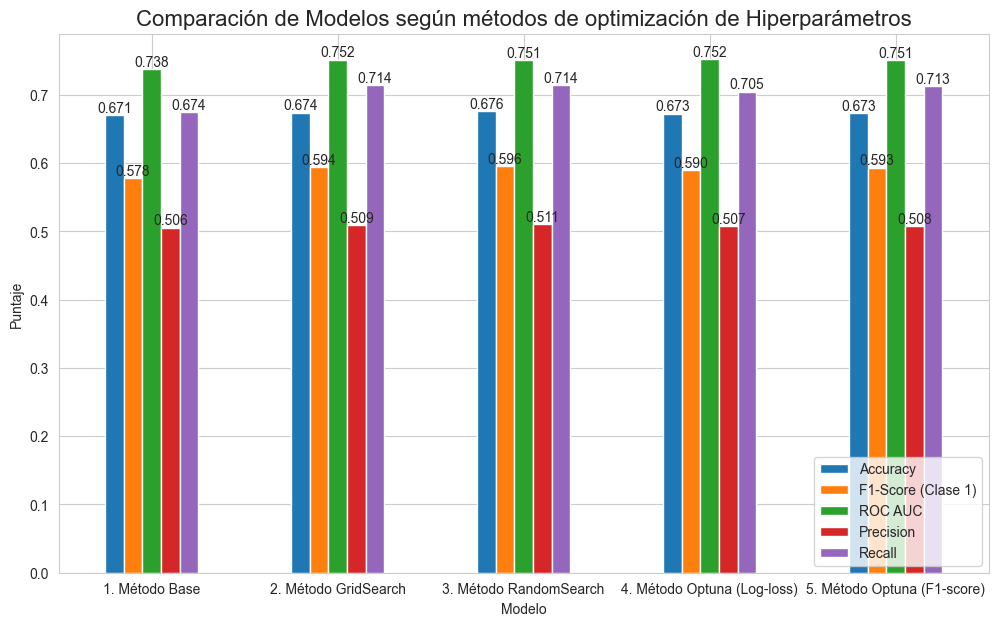

In [44]:
# Graficar la comparación
# 1. Crear el objeto de la figura y los ejes al graficar
ax = comparison_df.plot(kind='bar', figsize=(12, 7), rot=0) 

# 2. Configuración inicial del gráfico
plt.title('Comparación de Modelos según métodos de optimización de Hiperparámetros', fontsize=16)
plt.ylabel('Puntaje')
plt.legend(loc='lower right')

# 3. Iterar sobre las barras y añadir la anotación de texto
for container in ax.containers: # 'containers' contiene los grupos de barras (una para cada columna)
    ax.bar_label(container, fmt='%.3f') # Usa bar_label para la colocación automática
plt.show()

Según se observa en la gráfica, los 4 métodos de optimización de hiperparámetros muestran mejoras similares res en el rendimiento del modelo, respecto del modelo base XGBoost.

> ***De acuerdo con la métrica F1-Score, el mejor modelo sería el obtenido por búsqueda aleatoria: `Random Search`.***